In [1]:
import jax
import jax.numpy as jnp
import pennylane as qml
import pennylane.numpy as np


n = 2
dev = qml.device('default.mixed', wires=2*n)

@qml.qnode(dev)
def test(rho):
    qml.QubitDensityMatrix(rho, wires=range(0, n))

    # There is no problem without the following line
    qml.CNOT([0, n])
    
    return qml.probs(wires=range(n))

GHZ = [1 / np.sqrt(2), 0, 0, 1 / np.sqrt(2)]
rho = qml.math.dm_from_state_vector(GHZ)
test(rho)


array([0.5, 0. , 0. , 0.5])

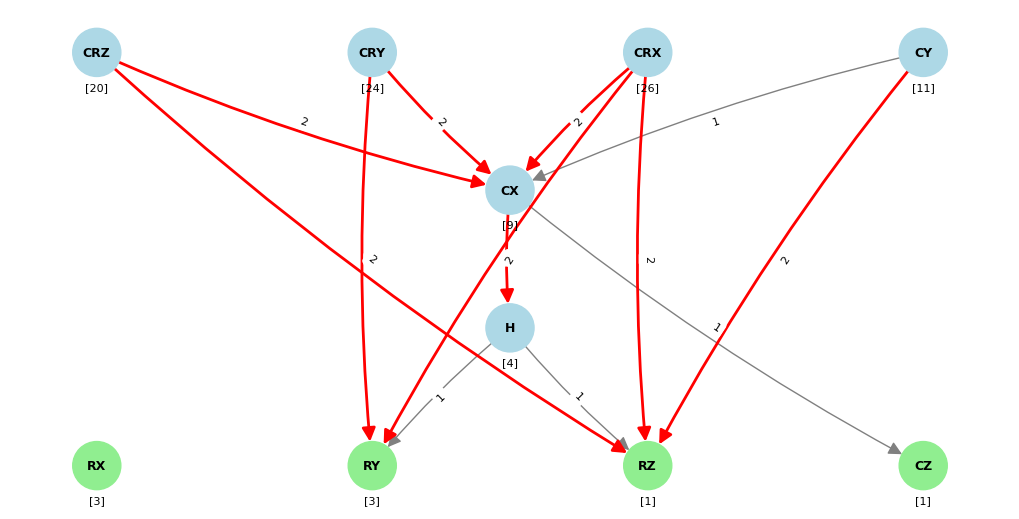

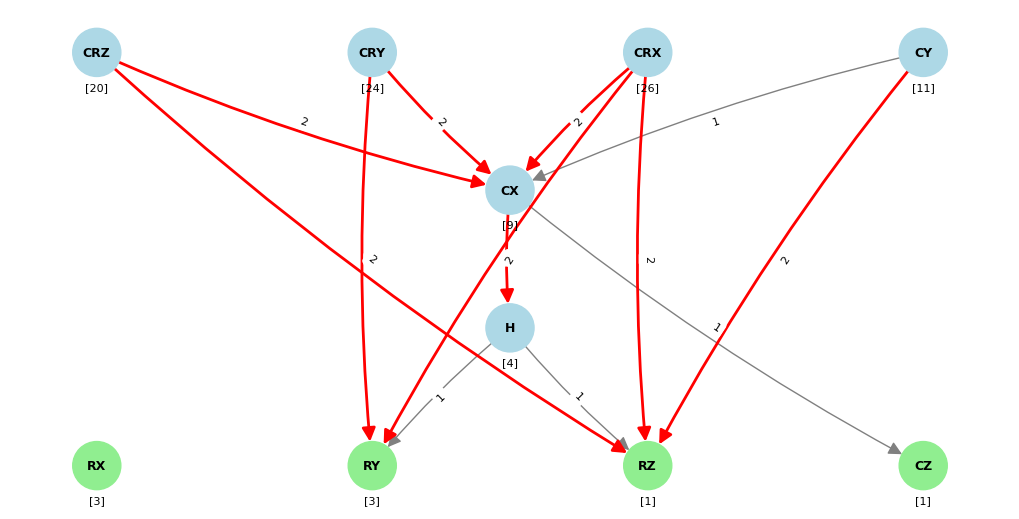

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from qml_essentials.ansaetze import PulseParams
from qml_essentials.ansaetze import PulseInformation as pinfo


def build_pulse_graph(root: PulseParams) -> nx.DiGraph:
    """
    Build a directed graph of PulseParams dependencies.
    Nodes: PulseParams instances.
    """
    G = nx.DiGraph()
    stack = [root]
    visited = set()

    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)

        # if node.is_leaf:
        #     params_str = ", ".join(f"{float(x):.6g}" for x in node._params)
        #     param_display = params_str                     # show actual params
        # else:
        params_str = ""
        param_display = f"{len(node.params)}"         # show total count

        if node not in G:
            G.add_node(
                node,
                name=node.name,
                params=params_str,        # raw param string (for leaves)
                param_display=param_display,  # what we actually draw
                is_leaf=node.is_leaf,
            )

        if not node.is_leaf:
            counts = {}
            for child in node.childs:
                counts[child] = counts.get(child, 0) + 1
            for child, w in counts.items():
                if G.has_edge(node, child):
                    G[node][child]["weight"] += w
                else:
                    G.add_edge(node, child, weight=w)
                if child not in visited:
                    stack.append(child)

    return G


def compute_leaf_distances(G: nx.DiGraph):
    """
    For each node, compute the maximum distance (in edges) to any leaf below it.
    This makes nodes with longer dependency chains appear higher in the tree.
    """
    # distance_to_leaf[node] = 0 for leaves
    distance_to_leaf = {n: 0 for n, d in G.nodes(data=True) if d.get("is_leaf")}

    # Process nodes in reverse topological order
    for n in reversed(list(nx.topological_sort(G))):
        if G.out_degree(n) == 0:
            continue  # leaf already has distance 0
        # max(1 + child distance)
        child_dists = [1 + distance_to_leaf[c] for c in G.successors(n)]
        distance_to_leaf[n] = max(child_dists)

    return distance_to_leaf

def hierarchical_pos_from_leaf_distance(G: nx.DiGraph, scale_x=1.0, scale_y=1.0):
    """
    Construct a 'tree-like' layout where:
      - y is proportional to distance from leaf (nodes with longest chains higher up)
      - x spreads siblings to avoid overlap.
    """
    # Compute "height" = distance from leaf
    dist = compute_leaf_distances(G)
    max_h = max(dist.values()) if dist else 0

    # Group nodes by height
    layers = {}
    for n, h in dist.items():
        layers.setdefault(h, []).append(n)

    # Assign x within each layer equally spaced
    pos = {}
    for h, nodes in sorted(layers.items()):  # from 0 (leaves) up
        k = len(nodes)
        if k == 1:
            xs = [0.0]
        else:
            xs = [i - (k - 1) / 2 for i in range(k)]
        for n, x in zip(nodes, xs):
            # y = h, with leaves at y=0, more complex gates higher (larger h)
            pos[n] = (x * scale_x, h * scale_y)

    return pos


def draw_pulse_graph(G: nx.DiGraph, figsize=(10, 5)):
    pos = hierarchical_pos_from_leaf_distance(G, scale_x=1.5, scale_y=1)
    plt.figure(figsize=figsize)

    node_colors = [
        "lightgreen" if G.nodes[n].get("is_leaf") else "lightblue"
        for n in G.nodes
    ]

    edge_weights = [G[u][v].get("weight", 1) for u, v in G.edges]
    max_w = max(edge_weights) if edge_weights else 1
    widths = [1 + 2 * (w - 1) / max_w for w in edge_weights]

    edge_colors = [
        "red" if G[u][v].get("weight", 1) > 1 else "gray"
        for u, v in G.edges
    ]

    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color=node_colors,
        node_size=1200,
        width=widths,
        edge_color=edge_colors,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.05",
    )

    # Gate name labels
    name_labels = {n: G.nodes[n]["name"] for n in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=name_labels, font_size=9, font_weight="bold")

    # Parameter / count labels below each node
    param_labels = {
        n: f"[{G.nodes[n]['param_display']}]" if G.nodes[n]["param_display"] else ""
        for n in G.nodes
    }
    offset_pos = {n: (x, y - 0.25) for n, (x, y) in pos.items()}
    nx.draw_networkx_labels(G, offset_pos, labels=param_labels, font_size=8)

    # Edge labels: show weight if > 1
    edge_labels = {
        (u, v): G[u][v]["weight"]
        for u, v in G.edges
        if G[u][v].get("weight", 1)
    }
    
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.axis("off")
    plt.show()

# Build global graph as before
top_roots = [pinfo.RX, pinfo.RY, pinfo.RZ, pinfo.CZ, pinfo.H, pinfo.CX, pinfo.CY, pinfo.CRX, pinfo.CRY, pinfo.CRZ]
G = nx.DiGraph()
for root in top_roots:
    Gi = build_pulse_graph(root)
    G = nx.compose(G, Gi)

draw_pulse_graph(G)


def build_pulse_graph(root: PulseParams) -> nx.DiGraph:
    """
    Build a directed graph of PulseParams dependencies.
    Nodes: PulseParams instances.
    """
    G = nx.DiGraph()
    stack = [root]
    visited = set()

    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)

        # if node.is_leaf:
        #     params_str = ", ".join(f"{float(x):.6g}" for x in node._params)
        #     param_display = params_str                     # show actual params
        # else:
        params_str = ""
        param_display = f"{len(node.params)}"         # show total count

        if node not in G:
            G.add_node(
                node,
                name=node.name,
                params=params_str,        # raw param string (for leaves)
                param_display=param_display,  # what we actually draw
                is_leaf=node.is_leaf,
            )

        if not node.is_leaf:
            counts = {}
            for child in node.childs:
                counts[child] = counts.get(child, 0) + 1
            for child, w in counts.items():
                if G.has_edge(node, child):
                    G[node][child]["weight"] += w
                else:
                    G.add_edge(node, child, weight=w)
                if child not in visited:
                    stack.append(child)

    return G


def compute_leaf_distances(G: nx.DiGraph):
    """
    For each node, compute the maximum distance (in edges) to any leaf below it.
    This makes nodes with longer dependency chains appear higher in the tree.
    """
    # distance_to_leaf[node] = 0 for leaves
    distance_to_leaf = {n: 0 for n, d in G.nodes(data=True) if d.get("is_leaf")}

    # Process nodes in reverse topological order
    for n in reversed(list(nx.topological_sort(G))):
        if G.out_degree(n) == 0:
            continue  # leaf already has distance 0
        # max(1 + child distance)
        child_dists = [1 + distance_to_leaf[c] for c in G.successors(n)]
        distance_to_leaf[n] = max(child_dists)

    return distance_to_leaf

def hierarchical_pos_from_leaf_distance(G: nx.DiGraph, scale_x=1.0, scale_y=1.0):
    """
    Construct a 'tree-like' layout where:
      - y is proportional to distance from leaf (nodes with longest chains higher up)
      - x spreads siblings to avoid overlap.
    """
    # Compute "height" = distance from leaf
    dist = compute_leaf_distances(G)
    max_h = max(dist.values()) if dist else 0

    # Group nodes by height
    layers = {}
    for n, h in dist.items():
        layers.setdefault(h, []).append(n)

    # Assign x within each layer equally spaced
    pos = {}
    for h, nodes in sorted(layers.items()):  # from 0 (leaves) up
        k = len(nodes)
        if k == 1:
            xs = [0.0]
        else:
            xs = [i - (k - 1) / 2 for i in range(k)]
        for n, x in zip(nodes, xs):
            # y = h, with leaves at y=0, more complex gates higher (larger h)
            pos[n] = (x * scale_x, h * scale_y)

    return pos


def draw_pulse_graph(G: nx.DiGraph, figsize=(10, 5)):
    pos = hierarchical_pos_from_leaf_distance(G, scale_x=1.5, scale_y=1)
    plt.figure(figsize=figsize)

    node_colors = [
        "lightgreen" if G.nodes[n].get("is_leaf") else "lightblue"
        for n in G.nodes
    ]

    edge_weights = [G[u][v].get("weight", 1) for u, v in G.edges]
    max_w = max(edge_weights) if edge_weights else 1
    widths = [1 + 2 * (w - 1) / max_w for w in edge_weights]

    edge_colors = [
        "red" if G[u][v].get("weight", 1) > 1 else "gray"
        for u, v in G.edges
    ]

    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color=node_colors,
        node_size=1200,
        width=widths,
        edge_color=edge_colors,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.05",
    )

    # Gate name labels
    name_labels = {n: G.nodes[n]["name"] for n in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=name_labels, font_size=9, font_weight="bold")

    # Parameter / count labels below each node
    param_labels = {
        n: f"[{G.nodes[n]['param_display']}]" if G.nodes[n]["param_display"] else ""
        for n in G.nodes
    }
    offset_pos = {n: (x, y - 0.25) for n, (x, y) in pos.items()}
    nx.draw_networkx_labels(G, offset_pos, labels=param_labels, font_size=8)

    # Edge labels: show weight if > 1
    edge_labels = {
        (u, v): G[u][v]["weight"]
        for u, v in G.edges
        if G[u][v].get("weight", 1)
    }
    
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.axis("off")
    plt.show()

# Build global graph as before
top_roots = [pinfo.RX, pinfo.RY, pinfo.RZ, pinfo.CZ, pinfo.H, pinfo.CX, pinfo.CY, pinfo.CRX, pinfo.CRY, pinfo.CRZ]
G = nx.DiGraph()
for root in top_roots:
    Gi = build_pulse_graph(root)
    G = nx.compose(G, Gi)

draw_pulse_graph(G)

In [13]:
from qml_essentials.model import Model
import pennylane.numpy as np

model = Model(
    n_qubits=2,
    n_layers=1,
    circuit_type="Circuit_19",
    output_qubit=-1
)
rng=np.random.default_rng(0)
inputs = np.array([[0],[1]])
for i in range(10):
    model.initialize_params(rng=rng)
    outputs = model(inputs=inputs, force_mean=True, gate_mode="pulse")
    print(f"{i}: {outputs}")


/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumP

0: [-0.0538979 -0.1929593]


/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumP

1: [-0.23815115  0.06034362]


/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumP

...

3: [ 0.20719586 -0.13680148]


/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumP

4: [-0.46206898 -0.32048698]


/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/lc3267/Documents/CodeWorkspace/pulse-level-quantum-fourier-models/.venv/lib/python3.11/site-packages/pennylane/math/interface_utils.py:127: UserWarning: Contains tensors of types {'jax', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


KeyboardInterrupt: 